In [1]:
import pandas as pd
import matplotlib.pyplot  as plt
from metrics import metrics
from model import generics
from scipy.stats import wilcoxon
pd.set_option('display.max_rows', 2000)
pd.set_option('display.max_columns', 2000)
%load_ext autoreload
%autoreload 2

In [2]:
experiment_id = 'hourwindspeed'

In [3]:
df_mean_metrics, df_all_metrics, df_prevs = metrics.open_fold_result(experiment_id, normalize=False)

/home/domingosjr/experiments/src/metrics/metrics.py:216: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_metric = pd.DataFrame(all_metrics).fillna(-1).infer_objects(copy=False)
/home/domingosjr/experiments/src/metrics/metrics.py:216: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_metric = pd.DataFrame(all_metrics).fillna(-1).infer_objects(copy=False)
/home/domingosjr/experiments/src/metrics/metrics.py:216: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_obje

In [4]:
len([c for c in df_mean_metrics.reset_index()['model'].unique().tolist() if 'svrbagg1' in c])

0

In [5]:
df_mean_metrics.reset_index()['model'].unique()

array(['24arima', '24combmean', '24elm', '24kan', '24mlp', '24nhits',
       '24rf', '24svr', '24tcn', '48arima', '48combmean', '48elm',
       '48kan', '48mlp', '48nhits', '48rf', '48svr', '48tcn', '72arima',
       '72combmean', '72elm', '72kan', '72mlp', '72nhits', '72rf',
       '72svr', '72tcn'], dtype=object)

In [6]:
df_mean_metrics.columns

Index(['MSE', 'RMSE', 'MAPE', 'SMAPE', 'MAE', 'theil', 'ARV', 'IA', 'POCID',
       'val_metric', 'time_testing', 'time_training'],
      dtype='object')

In [7]:
df_mean_metrics.reset_index().sort_values(['ts', 'model'])[['ts', 'model', "MSE", 'MAPE', 'MAE']]

,ts,model,MSE,MAPE,MAE
0,windspeedcampinagrandehour,24arima,0.643935,15.689360,0.606614
1,windspeedcampinagrandehour,24combmean,0.594258,14.744894,0.585192
2,windspeedcampinagrandehour,24elm,0.624750,15.338520,0.604254
3,windspeedcampinagrandehour,24kan,0.622923,15.886215,0.605986
4,windspeedcampinagrandehour,24mlp,0.698037,15.545855,0.646099
5,windspeedcampinagrandehour,24nhits,0.608676,15.580996,0.597102
6,windspeedcampinagrandehour,24rf,0.665557,15.247000,0.626130
7,windspeedcampinagrandehour,24svr,0.640493,14.538952,0.599040
8,windspeedcampinagrandehour,24tcn,0.734185,17.310114,0.656862
9,windspeedcampinagrandehour,48arima,0.856372,18.517944,0.710034


In [8]:
filters = df_mean_metrics.reset_index()['model'].isin(
    ['1arima',  '1kanval', '1ma', '1nhits', '1rw', '1svr', '1tcn', 'hmrc450k25',
     '1elm','1scn'
     #'1elmbagg500.80.8', '1elmbagg500.80.8k25', '1elmbagg500.80.8rc450k25',
     '1mlp', 
     #'1mlpbagg500.80.8', '1mlpbagg500.80.8k25', '1mlpbagg500.80.8rc450k25',
      '1svr', '1svrbagg500.80.8', '1svrbagg500.80.8rc100k20', '1svrbagg500.80.8k20',
      '1elm', '1elmbagg500.80.8', '1elmbagg500.80.8rc100k20', '1elmbagg500.80.8k20',
     'combmean', 'hmrc20k3'
     ])

In [9]:
#df_mean_metrics[filters.values].reset_index().sort_values(by=['ts', 'model'])[['ts', 'model', 'RMSE', 'SMAPE', 'MAE']]
df_mean_metrics.reset_index().sort_values(by=['ts', 'model'])[['ts', 'model', 'RMSE',  'MAE' ,'MAPE']]

,ts,model,RMSE,MAE,MAPE
0,windspeedcampinagrandehour,24arima,0.802456,0.606614,15.689360
1,windspeedcampinagrandehour,24combmean,0.770877,0.585192,14.744894
2,windspeedcampinagrandehour,24elm,0.790363,0.604254,15.338520
3,windspeedcampinagrandehour,24kan,0.789239,0.605986,15.886215
4,windspeedcampinagrandehour,24mlp,0.835475,0.646099,15.545855
5,windspeedcampinagrandehour,24nhits,0.780160,0.597102,15.580996
6,windspeedcampinagrandehour,24rf,0.815815,0.626130,15.247000
7,windspeedcampinagrandehour,24svr,0.800308,0.599040,14.538952
8,windspeedcampinagrandehour,24tcn,0.856176,0.656862,17.310114
9,windspeedcampinagrandehour,48arima,0.925404,0.710034,18.517944


In [10]:
metric = 'RMSE'

proposed_list = []
for k, df in df_mean_metrics.reset_index().groupby('ts'):
    #arima = df[df['model'] == 'arima'][metric].iloc[0]
    #svr = df[df['model'] == 'arima'][metric].iloc[0]
    #mlp = df[df['model'] == 'arima'][metric].iloc[0]

    #df_arima[k] = (df.set_index('model')[metric] < arima)
    #df_svr[k] = (df.set_index('model')[metric] < svr)
    #df_mlp[k] = (df.set_index('model')[metric] < mlp)

    svr_proposed = df[( (df['model'].str.contains("1ammeanenscdsrc12k10")))].copy()
    if svr_proposed.shape[0]>0:
        proposed_list.append(pd.DataFrame(svr_proposed.iloc[svr_proposed['val_metric'].argmin()]).T)

    mlp_proposed = df[( (df['model'].str.contains("mlpkpssfalsep")) )].copy()
    if mlp_proposed.shape[0]>0:
        proposed_list.append(pd.DataFrame(mlp_proposed.iloc[mlp_proposed['val_metric'].argmin()]).T)
    order_personalizada =  [ 
               #'1mlp', 
              
              #'1ammean100', 
              #'1as', 
              #'1asens', 
              ##'1am' ,
               '1aquant',
               '1aquantmean100', 
              
              #'1ammean100cdsrc0.1k20', '1ammean100cdsrc0.1k40', '1ammean100cdsrc0.1k80' , 
              #'1ammean100cmostrecentrc1k20', '1ammean100cmostrecentrc1k40', '1ammean100cmostrecentrc1k80', 
               '1aquantmean100cdsrc0.1k20', '1aquantmean100cdsrc0.1k40', '1aquantmean100cdsrc0.1k80',
               '1aquantmean100cmostrecentrc1k20', '1aquantmean100cmostrecentrc1k40', '1aquantmean100cmostrecentrc1k80', 
               #'1asenscdsrc0.1k20',  '1asenscdsrc0.1k40',  '1asenscdsrc0.1k80',
               #'1asenscmostrecentrc1k20',  '1asenscmostrecentrc1k40', '1asenscmostrecentrc1k80',
                '1arima',
                '1svr', 
            ]
    proposed_list.append(
        df[df['model'].isin(
            order_personalizada
        )]
    )

In [11]:
df_show = pd.concat(proposed_list)[['ts', 'model', 'RMSE', 'MAPE', 'MAE']]

df_show['model'] = pd.Categorical(df_show['model'], categories=order_personalizada, ordered=True)

In [12]:
df_show.sort_values(['ts', 'model'])

,ts,model,RMSE,MAPE,MAE


In [13]:
def get_hipotesis(metrics_p1, metrics_p2):
    stat, p = wilcoxon(metrics_p1, metrics_p2, alternative='two-sided')
    # interpret
    alpha = 0.05
    if p > alpha:
        #print('Same distribution (fail to reject H0)')
        to_print = '\'='
    else:
        stat, p = wilcoxon(metrics_p1, metrics_p2, alternative='less')
        if p > alpha:
             to_print = '\'-'
        else:
            to_print = '\'+'
        #print('Different distribution (reject H0)')

    return to_print

def columns_x_columns(df_pivot):
    all_comparasion = []
    for c1 in df_pivot.columns:
        result_base = {}
        result_base['base'] = c1 
        for c2 in df_pivot.columns:
            if c1!=c2:
                result = get_hipotesis(df_pivot[c1], df_pivot[c2])
                result_base[c2] = result
            else:
                result_base[c2] = '\'='
        all_comparasion.append(result_base)
    
    df_result = pd.DataFrame(all_comparasion)
    
    display(df_result[df_result['base'] == '1mpfs2050'])

all_execs = []
for key, df_serie in df_all_metrics.groupby(['ts']):
    try:
        print(key)
        df_pivot = df_serie.pivot(columns= 'model', values='RMSE' )
        df_pivot = df_pivot.ffill()
        to_plot = df_serie.pivot(columns= 'model', values='RMSE' )[[
            '1arima', '1elm', '1kan', '1mlp', '1mp2050', '1mpfs2050', '1nhits', '1svr', '1tcn', '1scn']
            ]
        
        ax = to_plot.rename(columns={
            '1arima': 'SARIMA',
            '1kanval': 'KAN',
            '1mlp': 'MLP',
            '1nhits':"NHITS",
            '1tcn': 'TCN',
            'combmean': 'HetMean',
            'hmrc20k3': 'HetDs',
           '1svrbagg500.80.8rc100k20': 'Proposed'
        }
        ).plot.box(figsize = (6,5), rot=90)
        ax.set_ylabel('SMAPE')
        ax.set_xlabel('Model')
        #plt.savefig(f'box{key[0]}.pdf', format='pdf', bbox_inches='tight')
        plt.show()
        columns_x_columns(df_pivot)
    except:
        print(f'error {key}')

('windspeedcampinagrandehour',)
error ('windspeedcampinagrandehour',)
('windspeedcaruaruhour',)
error ('windspeedcaruaruhour',)
('windspeedcastelodopiauihour',)
error ('windspeedcastelodopiauihour',)
('windspeedmaceiohour',)
error ('windspeedmaceiohour',)
('windspeedsalvadorhour',)
error ('windspeedsalvadorhour',)


In [14]:
df_all_metrics[['horizonte', 'name']] = df_all_metrics['model'].str.extract(r'(\d+)([a-zA-Z]+)')

In [15]:
df_all = df_all_metrics.reset_index()

In [16]:
df_all = df_all.pivot(index=['index', 'ts', 'horizonte' ], values='RMSE', columns='name').groupby(['ts', 'horizonte']).ffill().reset_index()

In [17]:
df_all.head()

name,index,ts,horizonte,arima,combmean,elm,kan,mlp,nhits,rf,svr,tcn
0,0,windspeedcampinagrandehour,24,0.802456,0.765325,0.789140,0.784238,0.833368,0.773079,0.814789,0.800308,0.867779
1,0,windspeedcampinagrandehour,48,0.925404,0.855230,0.889082,0.876167,0.934697,0.868405,0.887018,0.902139,0.913852
2,0,windspeedcampinagrandehour,72,0.982239,0.897348,0.912326,0.917222,0.978508,0.916526,0.932121,0.990414,0.950502
3,0,windspeedcaruaruhour,24,0.696701,0.671337,0.678628,0.719585,0.656718,0.686767,0.664180,0.673837,0.742606
4,0,windspeedcaruaruhour,48,0.714013,0.710006,0.712492,0.778624,0.697122,0.753408,0.700130,0.694928,0.762345


In [18]:
df_all.columns

Index(['index', 'ts', 'horizonte', 'arima', 'combmean', 'elm', 'kan', 'mlp',
       'nhits', 'rf', 'svr', 'tcn'],
      dtype='object', name='name')

In [23]:
models = ['arima', 'elm', 'kan', 'mlp', 'nhits', 'rf', 'svr', 'tcn'#, 'combmean'
         ]

       meanrank    median       mad  ci_lower  ci_upper effect_size  \
rf     3.053333  0.815243  0.118072  0.711003  0.886144         0.0   
elm    3.180000  0.806802  0.099437  0.726778  0.876315     0.05216   
svr    3.473333  0.800308  0.126471  0.706346  0.902139    0.082336   
mlp    4.240000  0.834965  0.146333   0.69999  0.919844   -0.100053   
nhits  4.420000  0.846732  0.101507  0.773079  0.912043   -0.192907   
kan    5.200000  0.861409  0.141824  0.784238     0.918   -0.238629   
arima  5.666667  0.923780  0.200588  0.723192  0.946727   -0.444799   
tcn    6.766667  0.895775  0.127913  0.783867  0.972264   -0.441287   

        magnitude effect_size_above magnitude_above  
rf     negligible               0.0      negligible  
elm    negligible           0.05216      negligible  
svr    negligible          0.038501      negligible  
mlp    negligible         -0.170922      negligible  
nhits  negligible         -0.063025      negligible  
kan         small          -0.08027 

<Figure size 1200x500 with 0 Axes>

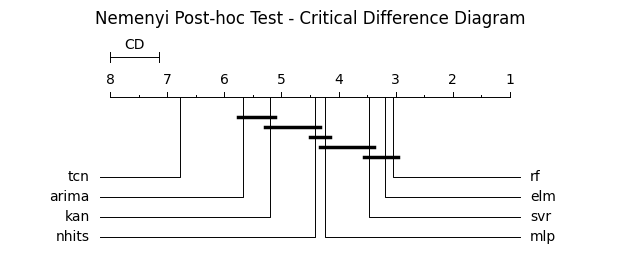


Ranks Médios:
       meanrank    median       mad  ci_lower  ci_upper effect_size  \
rf     3.053333  0.815243  0.118072  0.711003  0.886144         0.0   
elm    3.180000  0.806802  0.099437  0.726778  0.876315     0.05216   
svr    3.473333  0.800308  0.126471  0.706346  0.902139    0.082336   
mlp    4.240000  0.834965  0.146333   0.69999  0.919844   -0.100053   
nhits  4.420000  0.846732  0.101507  0.773079  0.912043   -0.192907   
kan    5.200000  0.861409  0.141824  0.784238     0.918   -0.238629   
arima  5.666667  0.923780  0.200588  0.723192  0.946727   -0.444799   
tcn    6.766667  0.895775  0.127913  0.783867  0.972264   -0.441287   

        magnitude effect_size_above magnitude_above  
rf     negligible               0.0      negligible  
elm    negligible           0.05216      negligible  
svr    negligible          0.038501      negligible  
mlp    negligible         -0.170922      negligible  
nhits  negligible         -0.063025      negligible  
kan         small    

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
from autorank import autorank, plot_stats
import numpy as np

# 1. Dados de exemplo (Substitua pelo seu DataFrame real)
# Cada coluna é um algoritmo, cada linha é um dataset/fold
data = df_all[models].copy()#[df_all['ts'].isin([
    #'austres',
   # 'milk',
    #'pollution',
    #'redwine',
    #'sunspot',
    #'temperature',
    #'ozon'
#])]#[models].copy()
data = data.rename(columns={
        '1arima': 'ARIMA',
        '1kan': 'KAN',
        '1mlp': 'MLP',
        '1nhits':"NHITS",
        '1tcn': 'TCN',
        '1svr': 'SVR',
        '1scn': 'SCN',
        '1elm': 'ELM',
       '1mpfs2050': 'Proposed'
    }
    )
# 2. Executar o autorank
# Se os dados não forem normais, ele usará Friedman automaticamente.
# Se você quiser garantir o comportamento não-paramétrico, 
# o parâmetro correto para versões recentes é 'approach'.
result = autorank(
    data, alpha=0.05, verbose=False, 
    order='ascending', 
    approach='frequentist'
)

# 3. Gerar o gráfico de Diferença Crítica (CD Diagram)
# O autorank só gera o CD diagram se o teste de Friedman for significativo
if result.posthoc == 'nemenyi':
    plt.figure(figsize=(12, 5))
    plot_stats(result)
    plt.title("Nemenyi Post-hoc Test - Critical Difference Diagram")
    plt.savefig(f'nemenyi.pdf', format='pdf', bbox_inches='tight')
    plt.show()
else:
    print(f"O teste post-hoc detectado foi: {result.posthoc}")
    print("Para gerar o CD diagram, o autorank precisa detectar dados não-paramétricos.")
    # Forçando o plot mesmo assim (se disponível para o teste detectado)
    plot_stats(result)
   

    plt.show()

# 4. Ver os ranks médios calculados
print("\nRanks Médios:")
print(result.rankdf)

In [21]:
print(f"Valor da Diferença Crítica (CD): {result.cd}")


Valor da Diferença Crítica (CD): 0.9808554943424792


In [22]:
# 1. O P-Value do teste global (Friedman)
print(f"P-value do Teste de Friedman: {result.pvalue}")

# 2. Ver se a diferença é significante (Comparando p-value com alpha)
is_significant = result.pvalue < 0.05
print(f"Existe diferença estatística global? {is_significant}")

P-value do Teste de Friedman: 3.5309632505020395e-77
Existe diferença estatística global? True
